<a href="https://colab.research.google.com/github/rupam241001001108-netizen/ML-techno-assignment/blob/main/Assigment4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Month with Highest Attendance: November (94%)
Average Attendance: 87.92%


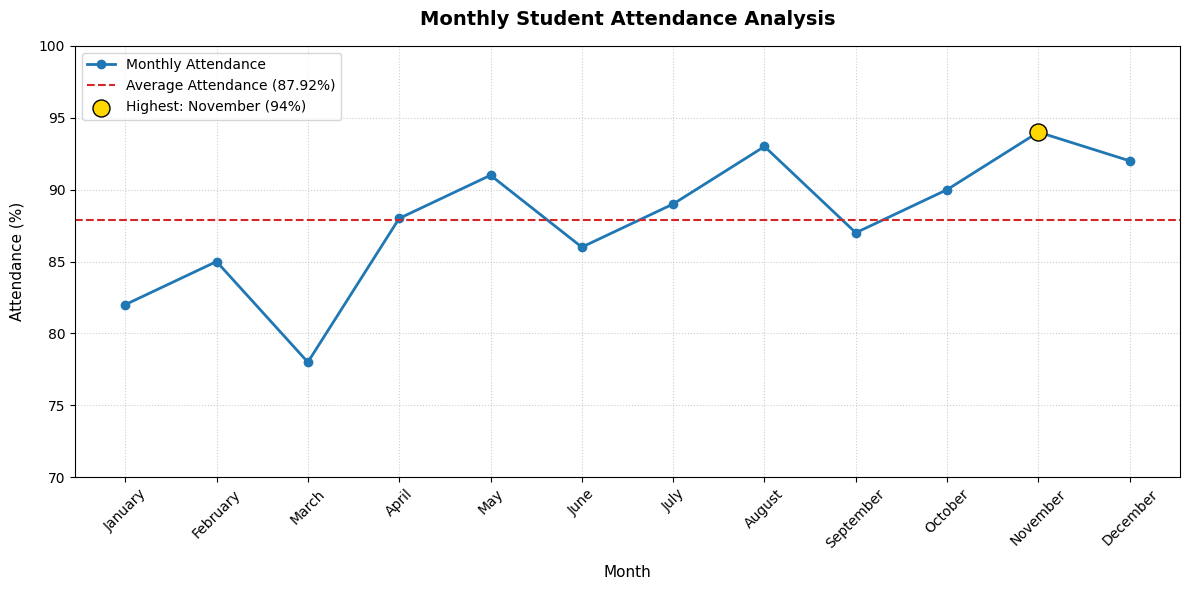

In [ ]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Prepare Data
data = {
    "Month": [
        "January",
        "February",
        "March",
        "April",
        "May",
        "June",
        "July",
        "August",
        "September",
        "October",
        "November",
        "December",
    ],
    "Attendance": [82, 85, 78, 88, 91, 86, 89, 93, 87, 90, 94, 92],
}
df = pd.DataFrame(data)

# Calculations
avg_attendance = df["Attendance"].mean()
max_row = df.loc[df["Attendance"].idxmax()]

# Print required outputs
print(
    f"Month with Highest Attendance: {max_row['Month']} ({max_row['Attendance']}%)"
)
print(f"Average Attendance: {avg_attendance:.2f}%")

# 2. Plotting
plt.figure(figsize=(12, 6))
plt.plot(
    df["Month"],
    df["Attendance"],
    marker="o",
    color="tab:blue",
    linewidth=2,
    label="Monthly Attendance",
)

# Reference line for average
plt.axhline(
    y=avg_attendance,
    color="tab:red",
    linestyle="--",
    linewidth=1.5,
    label=f"Average Attendance ({avg_attendance:.2f}%)",
)

# Highlight max attendance point
plt.scatter(
    max_row["Month"],
    max_row["Attendance"],
    color="gold",
    s=150,
    edgecolor="black",
    zorder=5,
    label=f"Highest: {max_row['Month']} ({max_row['Attendance']}%)",
)

# Graph annotations & formatting
plt.title(
    "Monthly Student Attendance Analysis",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Month", fontsize=11, labelpad=10)
plt.ylabel("Attendance (%)", fontsize=11, labelpad=10)
plt.xticks(rotation=45)
plt.ylim(70, 100)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

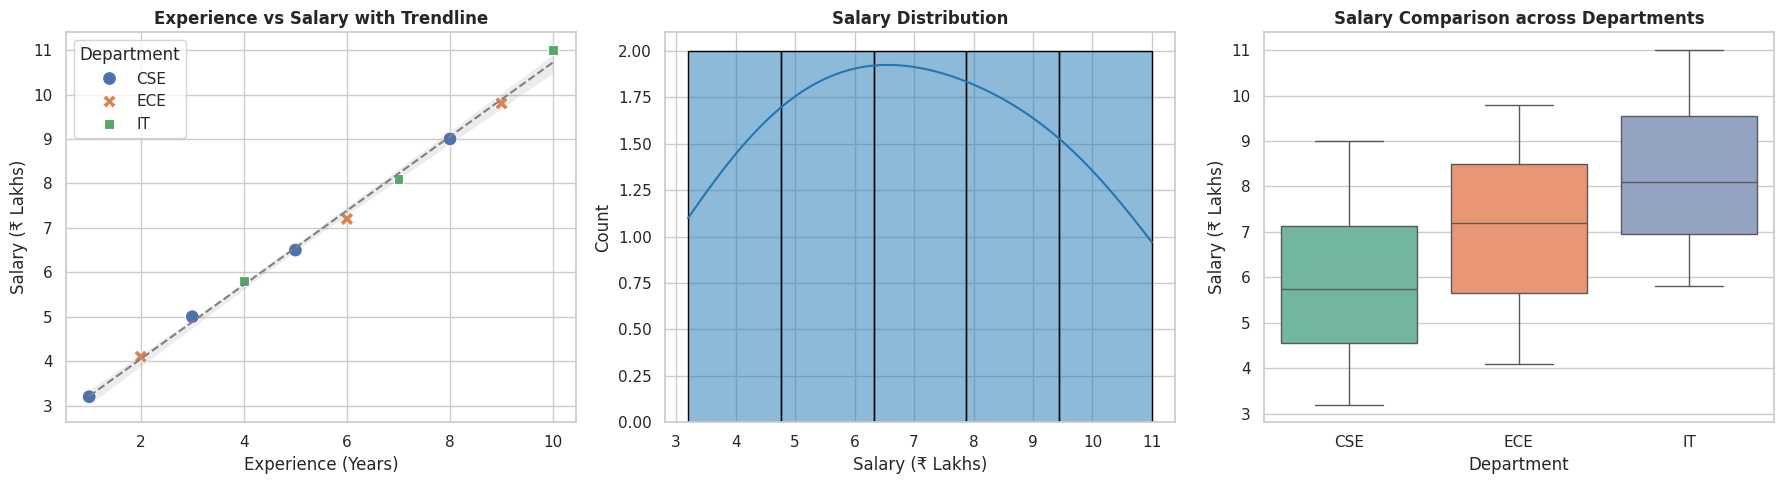

In [ ]:

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set visual theme
sns.set_theme(style="whitegrid")

# Create DataFrame
data = {
    "Experience": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Salary": [3.2, 4.1, 5.0, 5.8, 6.5, 7.2, 8.1, 9.0, 9.8, 11.0],
    "Department": [
        "CSE",
        "ECE",
        "CSE",
        "IT",
        "CSE",
        "ECE",
        "IT",
        "CSE",
        "ECE",
        "IT",
    ],
}
df = pd.DataFrame(data)

# Create 1x3 subplots for comprehensive analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Experience vs Salary (Scatter + Regression trend)
sns.regplot(
    data=df,
    x="Experience",
    y="Salary",
    scatter=False,
    ax=axes[0],
    color="gray",
    line_kws={"linestyle": "--", "linewidth": 1.5},
)
sns.scatterplot(
    data=df,
    x="Experience",
    y="Salary",
    hue="Department",
    style="Department",
    s=100,
    ax=axes[0],
)
axes[0].set_title("Experience vs Salary with Trendline", fontweight="bold")
axes[0].set_xlabel("Experience (Years)")
axes[0].set_ylabel("Salary (₹ Lakhs)")

# Plot 2: Salary Distribution
sns.histplot(
    data=df,
    x="Salary",
    kde=True,
    color="tab:blue",
    bins=5,
    ax=axes[1],
    edgecolor="black",
)
axes[1].set_title("Salary Distribution", fontweight="bold")
axes[1].set_xlabel("Salary (₹ Lakhs)")
axes[1].set_ylabel("Count")

# Plot 3: Salary across Departments (Boxplot)
sns.boxplot(
    data=df,
    x="Department",
    y="Salary",
    hue="Department",
    palette="Set2",
    legend=False,
    ax=axes[2],
)
axes[2].set_title("Salary Comparison across Departments", fontweight="bold")
axes[2].set_xlabel("Department")
axes[2].set_ylabel("Salary (₹ Lakhs)")

plt.tight_layout()
plt.show()

Dataset Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Area    12 non-null     int64
 1   Price   12 non-null     int64
dtypes: int64(2)
memory usage: 324.0 bytes
None

Missing Values Count:
 Area     0
Price    0
dtype: int64

Model Slope (Coefficient): 0.0387
Model Intercept: 0.8869

--- Evaluation Metrics ---
Mean Absolute Error (MAE): 0.3920
Mean Squared Error (MSE): 0.2001
Root Mean Squared Error (RMSE): 0.4474
R² Score: 0.9998


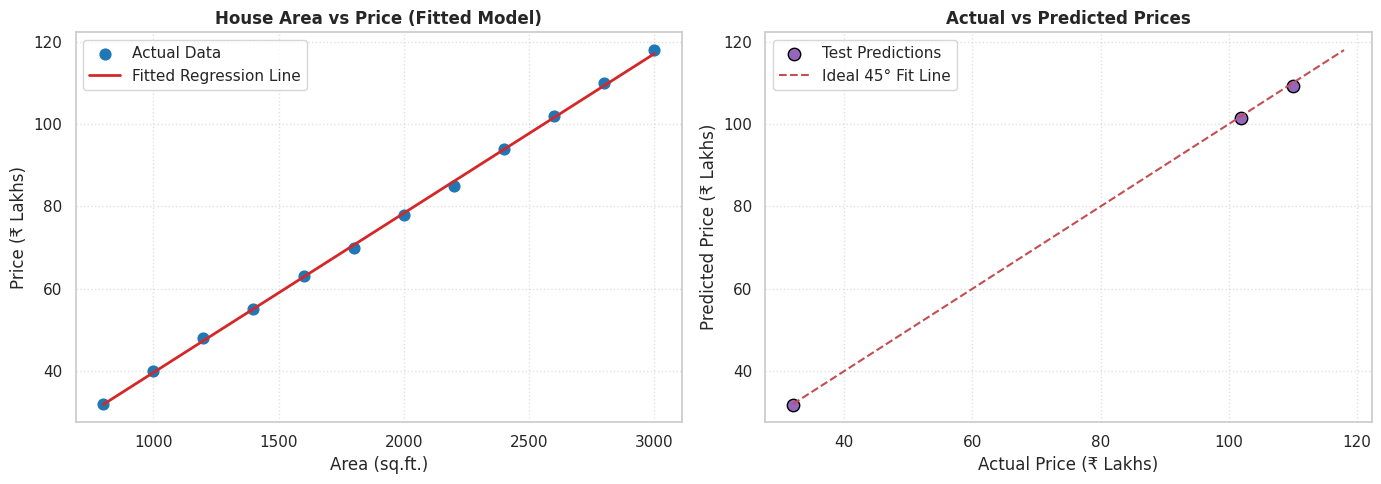


Predicted Price for a 2500 sq.ft. house: ₹97.73 Lakhs


In [ ]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# 1. Load Dataset into DataFrame
data = {
    "Area": [
        800,
        1000,
        1200,
        1400,
        1600,
        1800,
        2000,
        2200,
        2400,
        2600,
        2800,
        3000,
    ],
    "Price": [32, 40, 48, 55, 63, 70, 78, 85, 94, 102, 110, 118],
}
df = pd.DataFrame(data)

# 2. Basic Data Analysis & Missing Values Check
print("Dataset Summary:")
print(df.info())
print("\nMissing Values Count:\n", df.isnull().sum())

# 3. Train-Test Split (80-20 Split)
X = df[["Area"]]
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Model Training
model = LinearRegression()
model.fit(X_train, y_train)

# 5. Model Parameters
slope = model.coef_[0]
intercept = model.intercept_
print(f"\nModel Slope (Coefficient): {slope:.4f}")
print(f"Model Intercept: {intercept:.4f}")

# 6. Predict on Test Data
y_pred = model.predict(X_test)

# 7. Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"\n--- Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

# 8 & 9. Visualizations (Two subplots)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Regression Line with Full Dataset
axes[0].scatter(
    df["Area"], df["Price"], color="tab:blue", label="Actual Data", s=60
)
axes[0].plot(
    df["Area"],
    model.predict(df[["Area"]]),
    color="tab:red",
    linewidth=2,
    label="Fitted Regression Line",
)
axes[0].set_title("House Area vs Price (Fitted Model)", fontweight="bold")
axes[0].set_xlabel("Area (sq.ft.)")
axes[0].set_ylabel("Price (₹ Lakhs)")
axes[0].grid(True, linestyle=":", alpha=0.6)
axes[0].legend()

# Subplot 2: Actual vs Predicted on Test Data
axes[1].scatter(
    y_test, y_pred, color="tab:purple", s=80, edgecolor="black", label="Test Predictions"
)
axes[1].plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    "r--",
    lw=1.5,
    label="Ideal 45° Fit Line",
)
axes[1].set_title("Actual vs Predicted Prices", fontweight="bold")
axes[1].set_xlabel("Actual Price (₹ Lakhs)")
axes[1].set_ylabel("Predicted Price (₹ Lakhs)")
axes[1].grid(True, linestyle=":", alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.show()

# 10. Predict for 2500 sq.ft.
pred_2500 = model.predict(pd.DataFrame({"Area": [2500]}))[0]
print(f"\nPredicted Price for a 2500 sq.ft. house: ₹{pred_2500:.2f} Lakhs")